# Optuna analysis — диагностика тюнинга CG и joint

Что ищем:
1. **Corner-of-space** для per-CG студий (`cg_*.db`) — best value на границе search space?
2. **Importance + scatter** для `joint.db` — какие param реально двигают score, какие n_cand упёрлись в границы.
3. **Budget** — сумма n_cand vs cap=1600.
4. **Search space drift** — менялся ли search space mid-study (как у `cg_als.alpha`).

Вывод — список конкретных действий для Phase 2 (heuristic re-tune) и Phase 3 (расширение n_cand bounds в anti-overfit joint Optuna).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

OPTUNA_DIR = Path("../artifacts/optuna")
STUDIES = {
    "joint_v2": "joint_v2.db",
}

def load_study(study_name: str) -> optuna.Study:
    db_path = OPTUNA_DIR / STUDIES[study_name]
    return optuna.load_study(study_name=study_name, storage=f"sqlite:///{db_path}")

studies = {name: load_study(name) for name in STUDIES}
for name, st in studies.items():
    n_complete = sum(t.state == optuna.trial.TrialState.COMPLETE for t in st.trials)
    print(f"{name:18s} | trials={len(st.trials):4d} (complete={n_complete:4d}) | best={st.best_value:.4f}")

/Users/astrofimuk/REPS/mla_contest_04-2026/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


joint_v2           | trials=  60 (complete=  60) | best=405.1788


## 3. Joint Optuna — param importance

Чтобы понять какие n_cand_X / ranker params реально двигают score, считаем importance через fANOVA evaluator. CG с очень низкой importance — кандидаты на снижение n_cand (или удаление).

              param  importance category
      n_cand_repeat      0.5973   n_cand
     n_cand_esasrec      0.1633   n_cand
   n_cand_audio_knn     0.07299   n_cand
      learning_rate     0.06333   ranker
  n_cand_artist_pop     0.02125   n_cand
n_cand_recent_likes     0.01695   n_cand
   n_cand_album_pop     0.01509   n_cand
         iterations     0.01131   ranker
    n_cand_decaypop    0.009323   n_cand
              depth    0.008514   ranker
     n_cand_itemknn    0.008456   n_cand
        l2_leaf_reg    0.007609   ranker
         n_cand_als    0.004589   n_cand


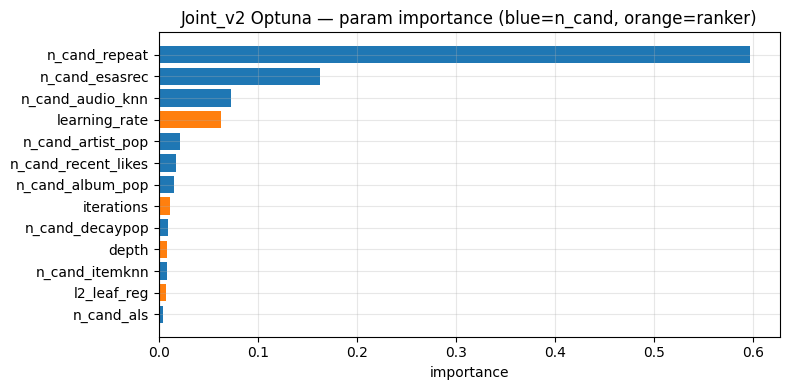

In [4]:
joint_v2 = studies["joint_v2"]
imp = optuna.importance.get_param_importances(joint_v2)
imp_df = pd.DataFrame({
    "param": list(imp.keys()),
    "importance": list(imp.values()),
}).sort_values("importance", ascending=False).reset_index(drop=True)
imp_df["category"] = imp_df["param"].apply(lambda p: "n_cand" if p.startswith("n_cand_") else "ranker")
print(imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tab:blue" if c == "n_cand" else "tab:orange" for c in imp_df["category"]]
ax.barh(imp_df["param"], imp_df["importance"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("importance")
ax.set_title("Joint_v2 Optuna — param importance (blue=n_cand, orange=ranker)")
plt.tight_layout()
plt.show()

## 4. Joint — n_cand vs score scatter

Для каждого `n_cand_X` строим scatter (param vs trial value). Если виден монотонный тренд к границе диапазона `[25, 350]` — этот CG **недотюнен** и стоит расширить bounds в Phase 3.

Complete trials: 60
n_cand columns: ['params_n_cand_album_pop', 'params_n_cand_als', 'params_n_cand_artist_pop', 'params_n_cand_audio_knn', 'params_n_cand_decaypop', 'params_n_cand_esasrec', 'params_n_cand_itemknn', 'params_n_cand_recent_likes', 'params_n_cand_repeat']


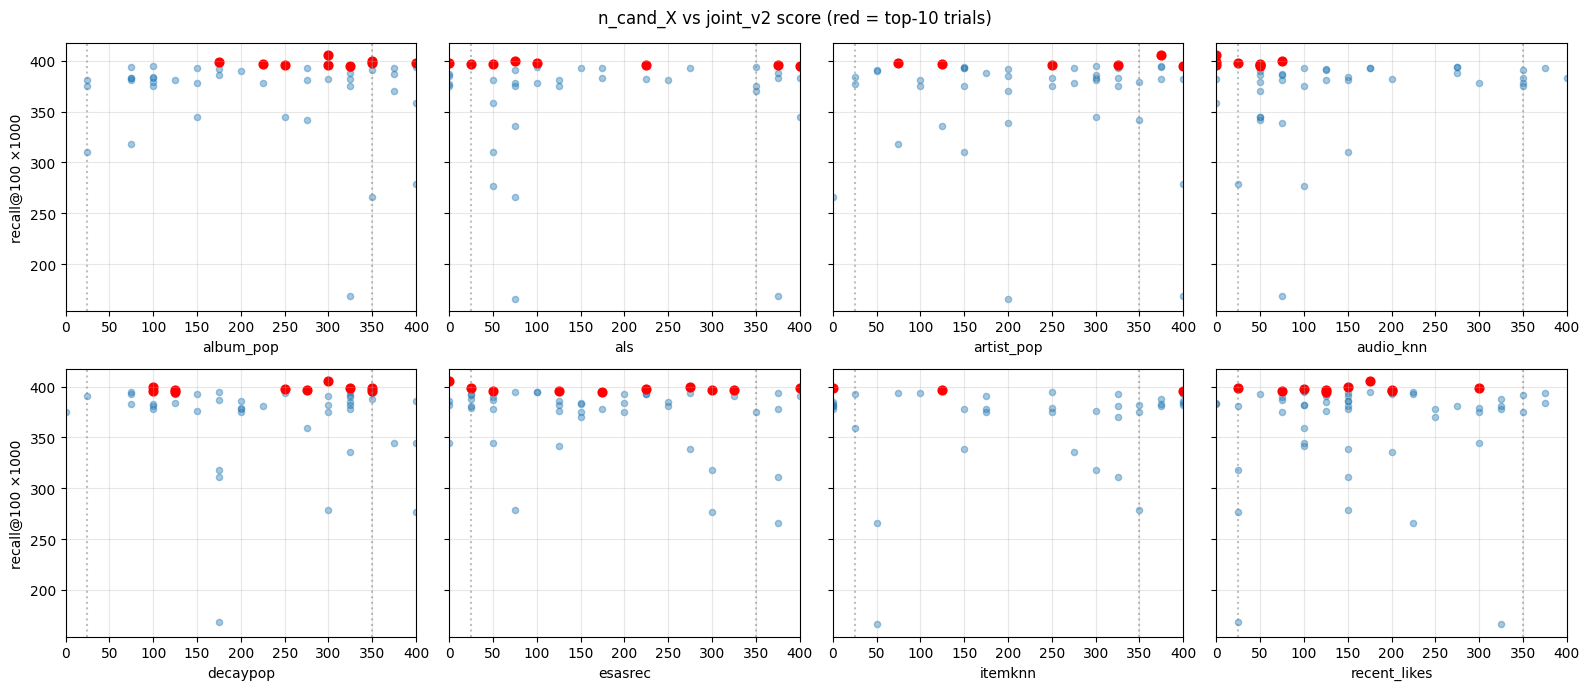

          cg  best_n_cand  top10_mean_n_cand  near_lower(25)  near_upper(350)
     itemknn          425                380           False             True
  artist_pop          375                345           False             True
   album_pop          300              317.5           False             True
    decaypop          300                230           False            False
      repeat          300                225           False            False
         als          500              222.5           False            False
     esasrec            0                190           False            False
recent_likes          175              147.5           False            False
   audio_knn            0                115           False            False


In [5]:
trials_df = joint_v2.trials_dataframe(attrs=("number", "value", "params", "state"))
trials_df = trials_df[trials_df["state"] == "COMPLETE"].copy()
n_cand_cols = [c for c in trials_df.columns if c.startswith("params_n_cand_")]
print(f"Complete trials: {len(trials_df)}")
print(f"n_cand columns: {n_cand_cols}")

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
best_value = trials_df["value"].max()
for ax, col in zip(axes.flat, n_cand_cols):
    cg_short = col.replace("params_n_cand_", "")
    ax.scatter(trials_df[col], trials_df["value"], alpha=0.4, s=20)
    # highlight top-10 trials
    top10 = trials_df.nlargest(10, "value")
    ax.scatter(top10[col], top10["value"], color="red", s=40, label="top-10")
    ax.set_xlabel(cg_short)
    ax.set_xlim(0, 400)
    ax.axvline(25, color="gray", ls=":", alpha=0.5)
    ax.axvline(350, color="gray", ls=":", alpha=0.5)
axes[0, 0].set_ylabel("recall@100 ×1000")
axes[1, 0].set_ylabel("recall@100 ×1000")
fig.suptitle("n_cand_X vs joint_v2 score (red = top-10 trials)")
plt.tight_layout()
plt.show()

# Summary table: per-CG best, mean of top-10 n_cand, distance to bounds
rows = []
for col in n_cand_cols:
    cg = col.replace("params_n_cand_", "")
    top10_mean = trials_df.nlargest(10, "value")[col].mean()
    best_val = trials_df.loc[trials_df["value"].idxmax(), col]
    rows.append({
        "cg": cg,
        "best_n_cand": int(best_val),
        "top10_mean_n_cand": round(top10_mean, 1),
        "near_lower(25)": top10_mean < 75,
        "near_upper(350)": top10_mean > 300,
    })
summary = pd.DataFrame(rows).sort_values("top10_mean_n_cand", ascending=False)
print(summary.to_string(index=False))

## 5. Budget — сколько использовали

Best trial #28: value=405.1788, total_budget=2375
Top-10 trials avg budget: 2172.5
Cap (config): 1600


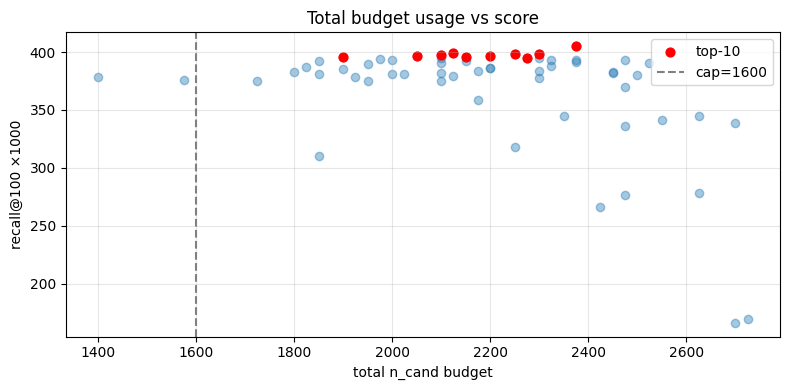

In [6]:
trials_df["total_budget"] = trials_df[n_cand_cols].sum(axis=1)
best_row = trials_df.loc[trials_df["value"].idxmax()]

trials_df = trials_df[trials_df['value'] > 0]

print(f"Best trial #{int(best_row['number'])}: value={best_row['value']:.4f}, total_budget={int(best_row['total_budget'])}")
print(f"Top-10 trials avg budget: {trials_df.nlargest(10, 'value')['total_budget'].mean():.1f}")
print(f"Cap (config): 1600")

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(trials_df["total_budget"], trials_df["value"], alpha=0.4)
top10 = trials_df.nlargest(10, "value")
ax.scatter(top10["total_budget"], top10["value"], color="red", s=40, label="top-10")
ax.axvline(1600, color="gray", ls="--", label="cap=1600")
ax.set_xlabel("total n_cand budget")
ax.set_ylabel("recall@100 ×1000")
ax.set_title("Total budget usage vs score")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
trials_df.sort_values(by="value", ascending=False).head(20)

,number,value,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_n_cand_album_pop,params_n_cand_als,params_n_cand_artist_pop,params_n_cand_audio_knn,params_n_cand_decaypop,params_n_cand_esasrec,params_n_cand_itemknn,params_n_cand_recent_likes,params_n_cand_repeat,state,total_budget
28,28,405.2,8,3000,1.177,0.09969,300,500,375,0,300,0,425,175,300,COMPLETE,2375
58,58,399.3,7,2500,2.104,0.146,350,75,450,75,100,275,500,150,150,COMPLETE,2125
52,52,398.5,8,2750,1.214,0.07753,175,475,450,0,350,25,500,25,250,COMPLETE,2250
36,36,398.1,8,3500,9.31,0.1225,400,100,75,450,325,400,0,300,250,COMPLETE,2300
55,55,397.3,8,3000,2.669,0.103,350,0,500,25,250,225,425,100,225,COMPLETE,2100
17,17,396.5,7,3500,7.171,0.1107,500,25,125,450,275,325,125,200,175,COMPLETE,2200
57,57,396.3,7,2000,3.084,0.1289,225,50,500,50,125,300,450,125,225,COMPLETE,2050
7,7,395.9,8,3250,1.431,0.05179,250,375,250,0,350,50,400,200,275,COMPLETE,2150
54,54,395.9,8,3000,2.369,0.09754,300,225,325,50,100,125,500,75,200,COMPLETE,1900
34,34,395.1,8,3250,1.856,0.08301,325,400,400,50,125,175,475,125,200,COMPLETE,2275


## 6. Joint — ranker params (best vs distribution)

Проверяем corner-of-space для 4 ranker hyperparams в joint.

In [9]:
best_joint = joint_v2.best_trial
rows = []
for pname in ["iterations", "depth", "learning_rate", "l2_leaf_reg"]:
    val = best_joint.params[pname]
    dist = best_joint.distributions[pname]
    log = getattr(dist, "log", False)
    cs = corner_score(val, dist.low, dist.high, log)
    rows.append({
        "param": pname,
        "best": val,
        "low": dist.low,
        "high": dist.high,
        "log": log,
        "corner_score": round(cs, 3),
        "flag": "⚠ CORNER" if abs(cs) > 0.85 else "",
    })
print(pd.DataFrame(rows).to_string(index=False))

        param    best  low  high   log  corner_score     flag
   iterations    3000 1500  4000 False           0.2         
        depth       8    4     8 False             1 ⚠ CORNER
learning_rate 0.09969 0.02  0.15  True         0.594         
  l2_leaf_reg   1.177    1    20  True        -0.891 ⚠ CORNER
